# **Нелинейные модели против южной погоды**

Цели и задачи проекта:
  1. Ознакомиться с данными и предоставленной базовой моделью
  2. Провести исследовательский анализ данных
  3. Обучить, протестировать и выбрать лучшую модель

# Постановка задачи машинного обучения

  - Необходимо решить задачу "обучения с учителем"
  - Целевой переменной явлется переменная 'Rented Bike Count' информирующая о количестве велосипедов, арендованных за конкретный час
  - В качестве основных метрик используются RMSE, R² и MAE. Критерием успешности проекта является улучшение ключевых метрик относительно базовой модели на кросс-валидации по обучающей выборке, и на тестовой выборке.

<a id='1'></a>
## **Часть 1. Работа с базовой моделью**

Сперва вы познакомитесь с тем, как работает baseline-модель, которую использовала компания BikeSouth до того, как обратилась к вам.

Компания предоставила:

* Pickle-файл — готовый обученный пайплайн без исходного кода. Доступен по пути здесь: `'/datasets/baseline_linear_regression_pipeline.pkl'`.

* Тренировочную и тестовую выборки, которые можно использовать для оценки модели. Они расположены здесь:

  * `'/datasets/ds_s14_train_data.csv'`;
  * `'/datasets/ds_s14_test_data.csv'`.


Базовую модель не нужно обучать заново — достаточно загрузить её и проверить качество.

**Совет:**
1. Убедитесь, что у вас есть доступ к `baseline_linear_regression_pipeline.pkl`, `ds_s14_train_data.csv` и `ds_s14_test_data.csv`.

2. Разделите тестовый набор на признаки `X` и целевую переменную `y`.

3. Загрузите .pkl-файл — это готовый пайплайн, который сам обрабатывает данные и делает предсказания. Модель автоматически применяет трансформации и возвращает прогнозы.

4. Посчитайте RMSE, MAE и R² — эти результаты нужны для оценки ваших улучшенных моделей в дальнейшей работе.

>Техническая напоминание: для работы с PKL-файлом нужно установить библиотеку joblib.

In [1]:
!pip install "scikit-learn==1.6.1" "numpy==1.26.4" -q
!pip install phik -q
!pip install optuna -q

In [2]:
import joblib
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score, make_scorer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, TargetEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_validate, cross_val_predict, train_test_split, cross_val_score, KFold
from sklearn.impute import SimpleImputer
import optuna
from sklearn.tree import DecisionTreeRegressor
from sklearn.inspection import permutation_importance
import phik
from time import time

In [3]:
# !pip freeze > requirements.txt

In [4]:
RANDOM_SEED = 42

In [5]:
train_df = pd.read_csv('/datasets/ds_s14_train_data.csv')
test_df = pd.read_csv('/datasets/ds_s14_test_data.csv')

for_final = test_df.copy()

linear_model = joblib.load('/datasets/baseline_linear_regression_pipeline.pkl')

In [6]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7008 entries, 0 to 7007
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               7008 non-null   float64
 1   Humidity(%)               6758 non-null   float64
 2   Wind speed (m/s)          6798 non-null   float64
 3   Visibility (10m)          6749 non-null   float64
 4   Dew point temperature     7008 non-null   float64
 5   Solar Radiation (MJ/m2)   6798 non-null   float64
 6   Rainfall(mm)              6746 non-null   float64
 7   Snowfall (cm)             6745 non-null   float64
 8   Seasons                   7008 non-null   object 
 9   Holiday                   7008 non-null   object 
 10  Functioning Day           7008 non-null   object 
 11  Time_Period_Evening       7008 non-null   bool   
 12  Time_Period_Late Evening  7008 non-null   bool   
 13  Time_Period_Morning       7008 non-null   bool   
 14  Time_Per

In [7]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1752 entries, 0 to 1751
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               1752 non-null   float64
 1   Humidity(%)               1680 non-null   float64
 2   Wind speed (m/s)          1700 non-null   float64
 3   Visibility (10m)          1680 non-null   float64
 4   Dew point temperature     1752 non-null   float64
 5   Solar Radiation (MJ/m2)   1700 non-null   float64
 6   Rainfall(mm)              1688 non-null   float64
 7   Snowfall (cm)             1691 non-null   float64
 8   Seasons                   1752 non-null   object 
 9   Holiday                   1752 non-null   object 
 10  Functioning Day           1752 non-null   object 
 11  Time_Period_Evening       1752 non-null   bool   
 12  Time_Period_Late Evening  1752 non-null   bool   
 13  Time_Period_Morning       1752 non-null   bool   
 14  Time_Per

In [8]:
linear_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Temperature', 'Humidity(%)',
                                                   'Wind speed (m/s)',
                                                   'Visibility (10m)',
                                                   'Dew point temperature',
                                                   'Solar Radiation (MJ/m2)',
                                                   'Rainfall(mm)',
                                                   'Snowfall (cm)']),
                                                 ('str_cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Seasons', 'Holiday',
                                                   'Functioning Day']),
                                                 ('ohe_pass', 'passthrough',
                                                  ['Time_Period_Evening',
                                                   'Time_Period_Late Evening',
                                                   'Time_Period_Morning',
                                                   'Time_Period_Night'])])),
                ('regressor', LinearRegression())])

Выгруженные данные представлены 2 датафреймами с информацией о погодных условиях, времени, является ли день выходным и т.д.:
  - train_data : 16 столбцов и 7008 строк - тренировочные данные для обучения модели
  - test_data : 16 столбцов и 1752 строки - данные для тестирования модели
  - в датафреймах есть пустые значения
  
В базовом пайплайне:
  - Числовые признаки:  пустые строки числовых признаков заполняются медианой, после чего масштабируются
  - Категориальные признаки: пустые строки заполняются модой, после чего кодируются с помощью OneHotEncoder
  - Бинарные признаки: не обрабатываются
  - В качестве модели используется линейная регрессия

In [9]:
X_train = train_df.drop(columns='Rented Bike Count')
y_train = train_df['Rented Bike Count']

X_test = test_df.drop(columns='Rented Bike Count')
y_test = test_df['Rented Bike Count']

In [10]:
print('Оценка базовой модели на тренировочной выборке')
y_pred_train = linear_model.predict(X_train)
print("RMSE:", round(root_mean_squared_error(y_train, y_pred_train), 2))
print("MAE: ", round(mean_absolute_error(y_train, y_pred_train), 2))
print("R²:  ", round(r2_score(y_train, y_pred_train), 3))

print('-' * 60)

print('Оценка базовой модели на тестовой выборке')
y_pred_test = linear_model.predict(X_test)
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_test), 2))
print("MAE: ", round(mean_absolute_error(y_test, y_pred_test), 2))
print("R²:  ", round(r2_score(y_test, y_pred_test), 3))

Оценка базовой модели на тренировочной выборке
RMSE: 412.53
MAE:  309.08
R²:   0.593
------------------------------------------------------------
Оценка базовой модели на тестовой выборке
RMSE: 411.56
MAE:  312.6
R²:   0.586


    Результаты текущей модели являются схожими на тренировочной и тестовой выборках, что свидетельствует о том, что модель не переобучается.
    Значение R2 не на высоком уровне, но являтся удовлетворительным
    Что касается ошибок, RMSE ~412 и MAE ~310 являются высокими значениями при том, что среднее значение 'Rented Bike Count' ~700

<a id='2'></a>
## **Часть 2. Улучшение модели — kNN и дерево решений**

Ваша задача — предложить более гибкую модель прогноза спроса на велосипеды, которая учитывает нюансы погоды и поведение клиентов.

Вы будете экспериментировать с моделями kNN и деревьями решений, используя подбор гиперпараметров Optuna.

<a id='2.1'></a>
**Шаг 1. Изучение данных**

Проведите исследовательский анализ данных:
1. Посмотрите на распределение целевой переменной `Rented Bike Count`. Определите, есть ли у неё выбросы или сильные сезонные колебания.
2. Постройте графики зависимости спроса от разных признаков.
3. Сравните спрос в разные сезоны и праздничные дни.
4. Рассчитайте корреляцию между признаками и целевой переменной.

**Совет:**

Не нужно сразу всё усложнять: начните с базовых графиков и описательной статистики.



---



In [11]:
df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Temperature               8760 non-null   float64
 1   Humidity(%)               8438 non-null   float64
 2   Wind speed (m/s)          8498 non-null   float64
 3   Visibility (10m)          8429 non-null   float64
 4   Dew point temperature     8760 non-null   float64
 5   Solar Radiation (MJ/m2)   8498 non-null   float64
 6   Rainfall(mm)              8434 non-null   float64
 7   Snowfall (cm)             8436 non-null   float64
 8   Seasons                   8760 non-null   object 
 9   Holiday                   8760 non-null   object 
 10  Functioning Day           8760 non-null   object 
 11  Time_Period_Evening       8760 non-null   bool   
 12  Time_Period_Late Evening  8760 non-null   bool   
 13  Time_Period_Morning       8760 non-null   bool   
 14  Time_Per

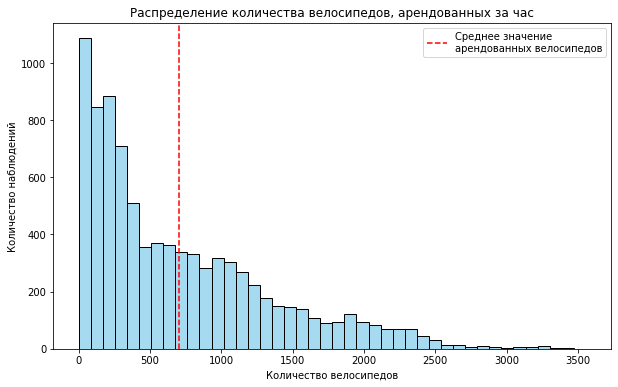

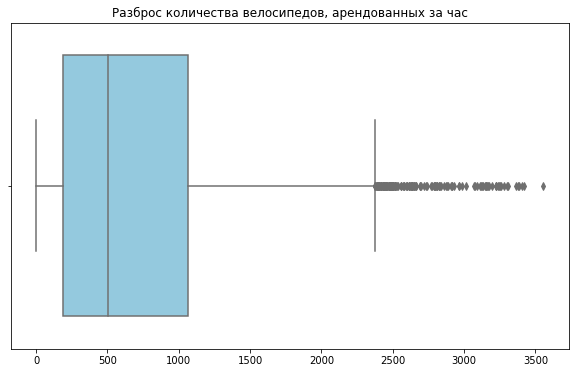

In [13]:
plt.figure(figsize=(10, 6))
sns.histplot(df, x='Rented Bike Count', color='skyblue')
plt.title('Распределение количества велосипедов, арендованных за час')
plt.ylabel('Количество наблюдений')
plt.xlabel('Количество велосипедов')
plt.axvline(x=df['Rented Bike Count'].mean(), color='r', linestyle='--',
           label='Среднее значение\nарендованных велосипедов')
plt.legend()
plt.show()


plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Rented Bike Count', color='skyblue')

plt.title('Разброс количества велосипедов, арендованных за час')
plt.xlabel('')
plt.show()

Чаще всего арендованное количество велосипедов за час составляет до 400. Среднее количество составляет около 700 велосипедов. В данных существуют выбивающиеся значения, однако они не выглядят достаточно реалистичными, поэтому оставляем их в данных.

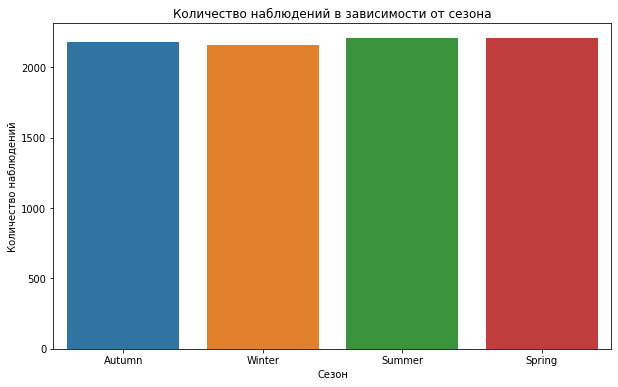

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Seasons')
plt.title('Количество наблюдений в зависимости от сезона')
plt.xlabel('Сезон')
plt.ylabel('Количество наблюдений')
plt.show()

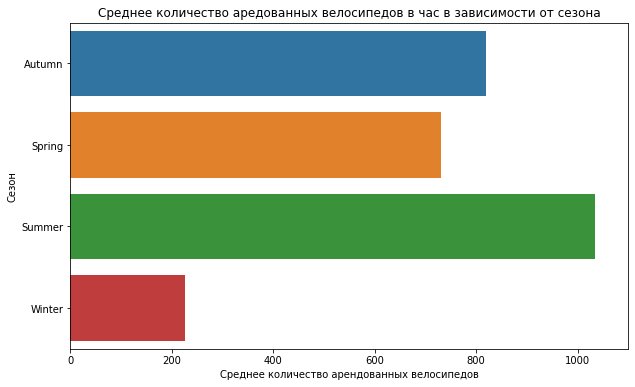

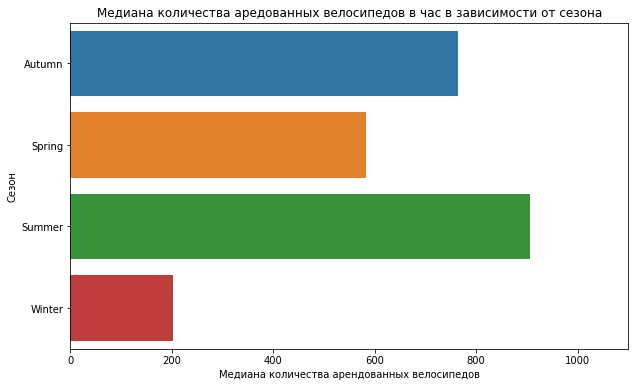

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df.groupby('Seasons')['Rented Bike Count'].mean().reset_index(),
            x="Rented Bike Count", y="Seasons")
plt.title('Среднее количество аредованных велосипедов в час в зависимости от сезона')
plt.xlabel('Среднее количество арендованных велосипедов')
plt.ylabel('Сезон')
plt.xlim(0, 1100)
plt.show()

print()

plt.figure(figsize=(10, 6))
sns.barplot(data=df.groupby('Seasons')['Rented Bike Count'].median().reset_index(),
            x="Rented Bike Count", y="Seasons")
plt.title('Медиана количества аредованных велосипедов в час в зависимости от сезона')
plt.xlabel('Медиана количества арендованных велосипедов')
plt.ylabel('Сезон')
plt.xlim(0, 1100)
plt.show()

Наибольшим спросом аренда велосипедов пользуется летом, в то время как зимой наоборот, спрос минимальный. Осенью и весной спрос примерно одинаковый, но с небольим уколоном с пользу осени. \
При сравнении медианы и среднего арендованных велосипедов в рамках сезонности, наиболее выделяющейся являтся весна - значение среднего ~720, значение медианы ~590, что свидетельствует о существовании больших выделяющихся значений в данных.

In [16]:
temp = {
    'Temperature' : 'Температура воздуха в градусах Цельсия',
    'Humidity(%)' : 'Относительная влажность воздуха, %',
    'Wind speed (m/s)' : 'Скорость ветра, м/с',
    'Visibility (10m)' : 'Видимость (в десятках метров)',
    'Dew point temperature' : 'Точка росы (°C)',
    'Solar Radiation (MJ/m2)' : 'Солнечная радиация (MJ/m²)',
    'Rainfall(mm)' : 'Количество осадков (мм)',
    'Snowfall (cm)' : 'Количество снега (см)'
}

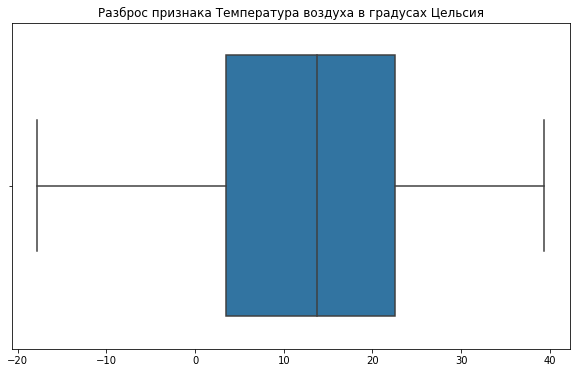

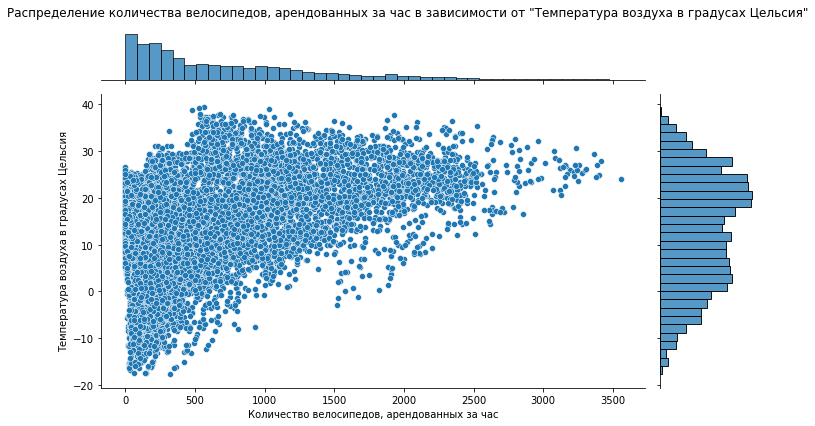

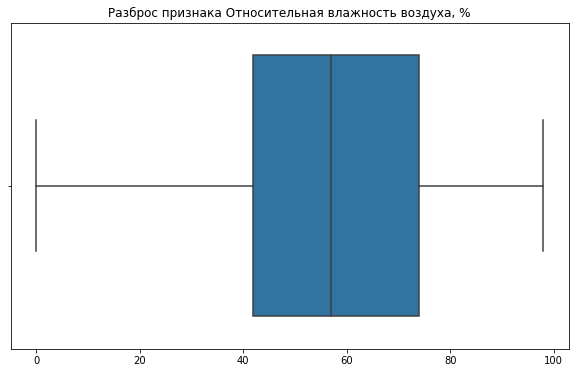

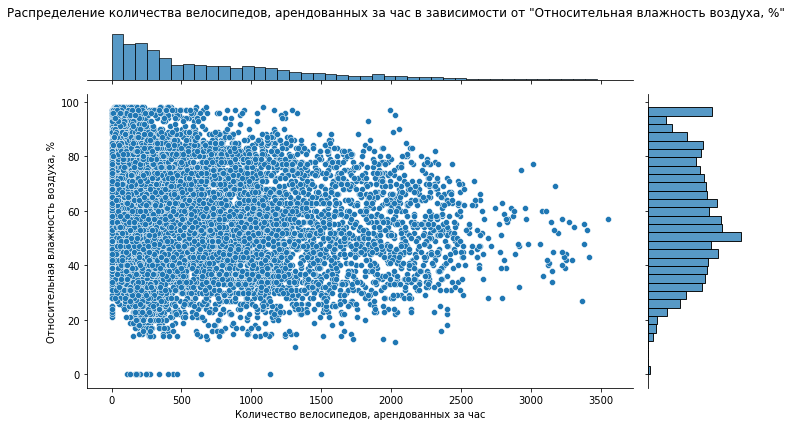

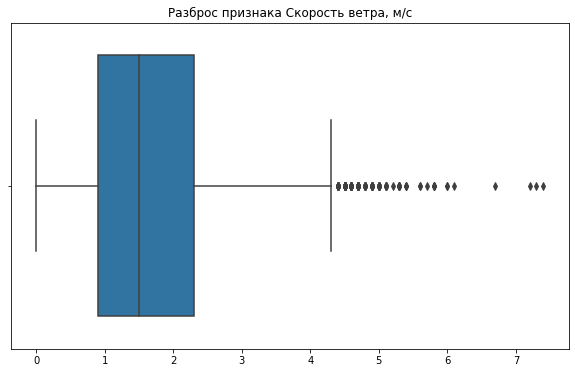

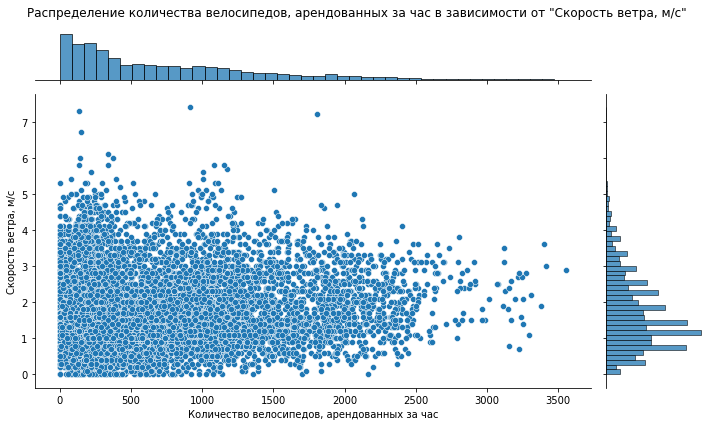

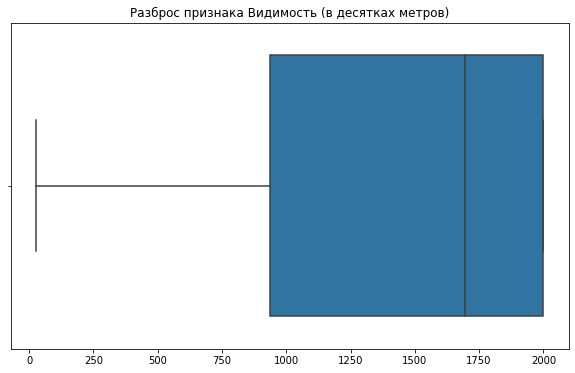

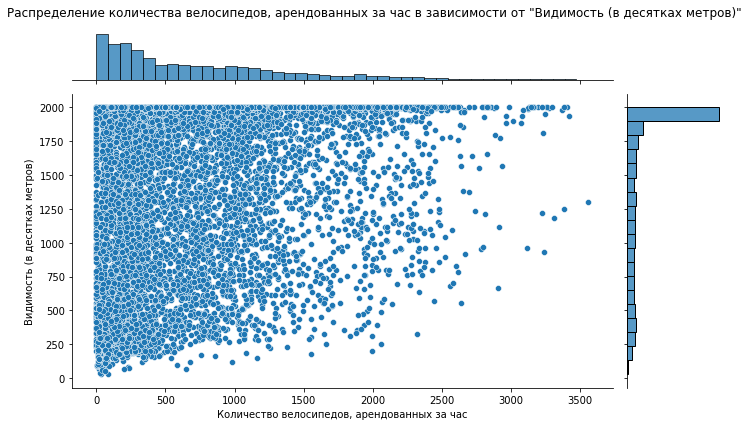

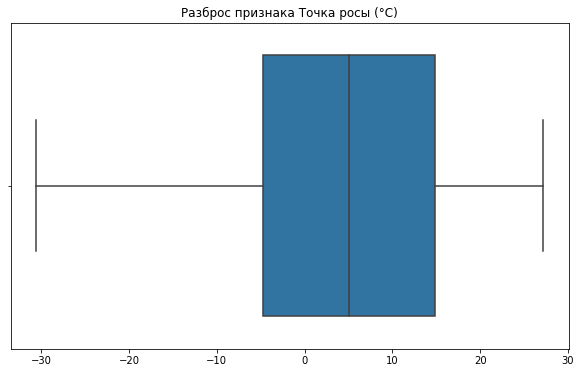

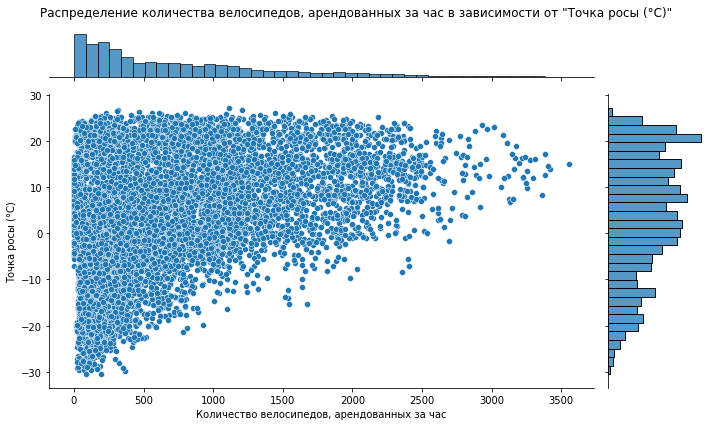

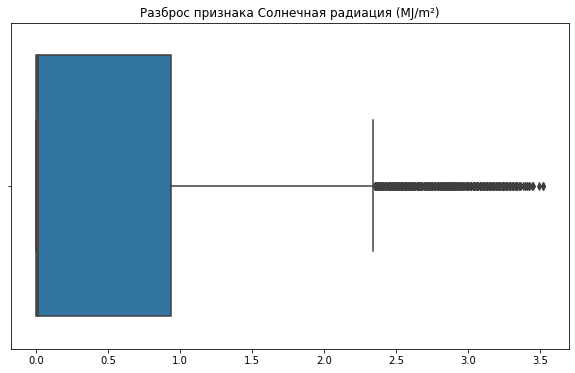

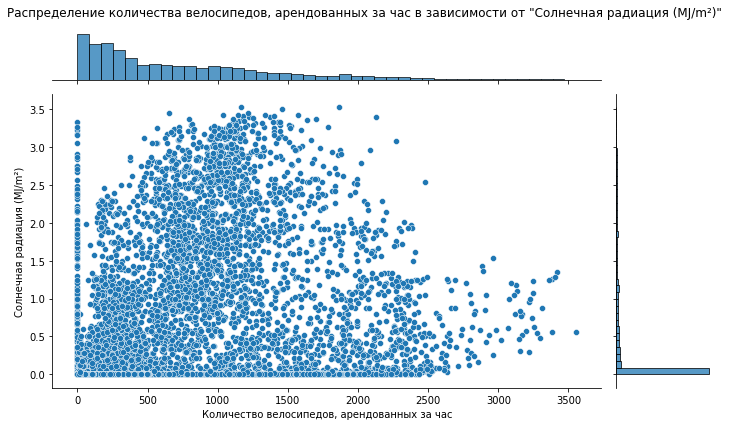

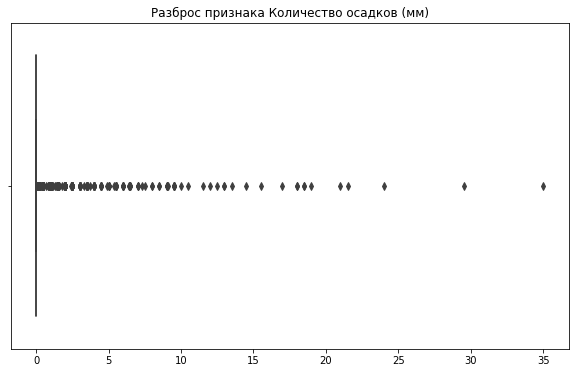

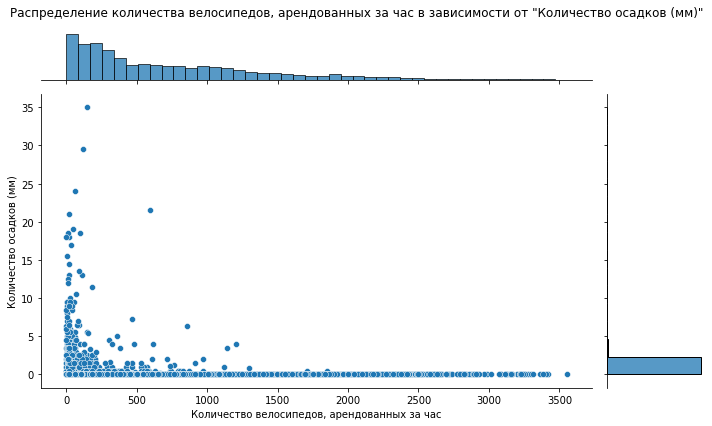

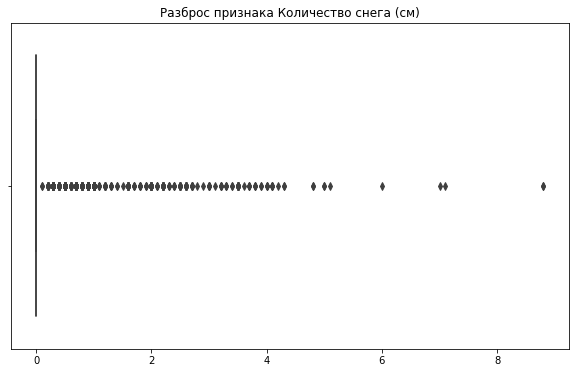

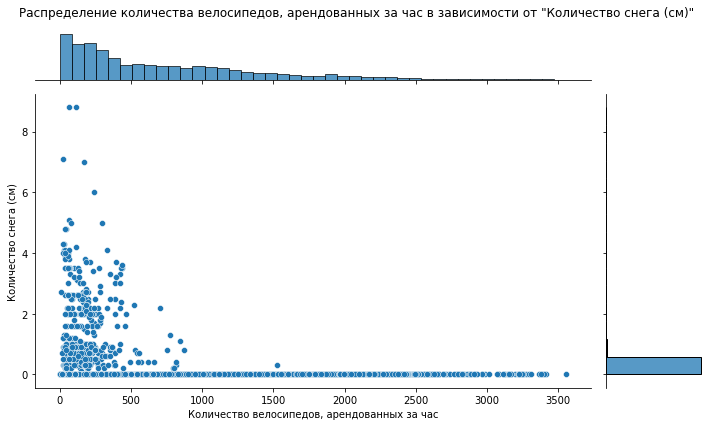

In [17]:
for i, j in temp.items():
    
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df, x=i)

    plt.title(f'Разброс признака {j}')
    plt.xlabel('')
    plt.show()
    
    joint = sns.jointplot(data=df, x='Rented Bike Count', y=i)
    joint.fig.set_size_inches(10, 6)
    joint.fig.suptitle(f'Распределение количества велосипедов, арендованных за час в зависимости от "{j}"')
    joint.set_axis_labels('Количество велосипедов, арендованных за час', f'{j}')
    plt.tight_layout()
    plt.show()

Выводы по данным:
  - Клиенты более склонны арендовывать велосипеды когда температура воздуха составяет от +10 до +30
  - Большинство велосипедов арендуется при относительной влажности воздуха от 30%, в промежутке от 0% до 30% наблюдается спад спроса
  - Наиболее активно велосипеды арендуются при скорости ветра от 0 до 2 м/с, далее, по мере увеличения скорости ветра, спрос снижается. При ветре со скоростью 5 м/с и более спроса почти что нет.
  - Подавляющая часть велосипедов арендуются при видимости 18-20 км, во все остальные периоды, за исключением 0-2 км, спрос одинаковый. При видимости 0-2 км спрос резко снижается.
  - Наиболее активно велосипеды арендуются при точкк росы от -10 до +25 градусов цельсия
  - Почти все велосипеды арендуются при низкой солнечной радиации (около 0 mj/m^2)
  - Почти все велосипеды арендуются при отсутсвии осадков
  - Почти все велосипеды арендуются при отсутсвии снега

В данных есть странные значения, касающиеся относительной влажности. В природе не может встречаться 0% относительной влажности, такие записи будем считать выбросами и заменим на пустые значения

In [18]:
train_df['Humidity(%)'] = train_df['Humidity(%)'].where(train_df['Humidity(%)']!=0)
test_df['Humidity(%)'] = test_df['Humidity(%)'].where(test_df['Humidity(%)']!=0)

In [19]:
temp = ['Holiday', 'Functioning Day',
        'Time_Period_Evening', 'Time_Period_Late Evening',
        'Time_Period_Morning', 'Time_Period_Night']

for i in temp:
    print(i)
    print(df[i].unique())
    print()

Holiday
['Holiday' 'No Holiday']

Functioning Day
['Yes' 'No']

Time_Period_Evening
[ True False]

Time_Period_Late Evening
[False  True]

Time_Period_Morning
[False  True]

Time_Period_Night
[False  True]



In [20]:
# Преобразуем бинарные признаки в True/False
train_df['Holiday'] = train_df['Holiday'] == 'Holiday'
test_df['Holiday'] = test_df['Holiday'] == 'Holiday'

train_df['Functioning Day'] = train_df['Functioning Day'] == 'Yes'
test_df['Functioning Day'] = test_df['Functioning Day'] == 'Yes'

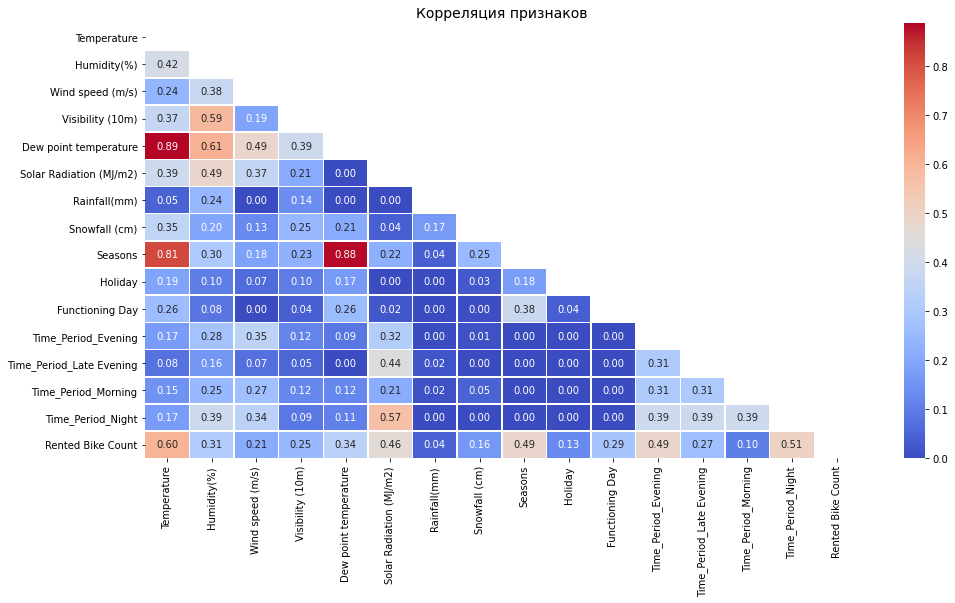

In [21]:
# Матрица корреляций
interval_cols = [
    'Temperature', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
    'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)', 'Rented Bike Count'
]
corr_data = df.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(16, 8))
mask = np.triu(np.ones_like(corr_data, dtype=bool))
sns.heatmap(data=corr_data, annot=True,
            fmt='.2f', linewidths=0.5,
            cmap='coolwarm', mask=mask,)
plt.title('Корреляция признаков', fontsize=14)
plt.show()

Наблюдается мультиколлиеарность в признаках:
  - temperature и seasons (0.81)
  - dew_point_temperature (0.89)
  - dew_point_temperature и seasons (0.88)

**Шаг 2. Разделение данных на тренировочную и валидационную выборки**

Используйте на этом этапе данные файла `ds_s14_train_data.csv`. Тестовый набор нужен только для финальной оценки модели после обучения и подбора гиперпараметров.

Подготовка данных вам понадобится, чтобы обучить модель и оценить её качество через валидацию.

---



In [22]:
X_train = train_df.drop(columns='Rented Bike Count')
y_train = train_df['Rented Bike Count']

X_test = test_df.drop(columns='Rented Bike Count')
y_test = test_df['Rented Bike Count']

print(f"Количество записей в тренировочной выборке: {X_train.shape[0]} \
({X_train.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100}%)")
print()
print(f"Количество записей в тестовой выборке: {X_test.shape[0]} \
({X_test.shape[0] / (X_train.shape[0] + X_test.shape[0]) * 100}%)")

Количество записей в тренировочной выборке: 7008 (80.0%)

Количество записей в тестовой выборке: 1752 (20.0%)


**Шаг 3. Обучение новых моделей**

kNN и деревья решений могут уловить нелинейные зависимости, недоступные линейной регрессии. Пора это проверить!

1. Подготовьте пайплайн для каждой модели:
    * Выполните предобработку данных.
    * Инициализизируйте регрессионные модели kNN и дерево решений.
4. Настройте базовые параметры моделей — например, `n_neighbors` для kNN, `max_depth` для дерева.

**Совет:**

Начинайте с базовых параметров, чтобы убедиться, что пайплайн работает. Оптимизацию параметров вы сделаете на следующем шаге.

---



In [23]:
def model_evaluate(model, X, y, n_splits=5):

    scoring_metrics = {
    'root_mean_squared_error': make_scorer(root_mean_squared_error),
    'r2_score': make_scorer(r2_score),
    'mean_absolute_error': make_scorer(mean_absolute_error)
    }
    
    outer_cv = KFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_SEED)
    
    start_time = time()
    
    cv_results = cross_validate(
        model,
        X, y,
        cv=outer_cv,
        scoring=scoring_metrics,
        n_jobs=-1
    )
    
    end_time = time()
    
    metrics = {}
    
    print(f"\n--- Средние Метрики Модели---")
    for metric in scoring_metrics.keys():
        mean_value = np.mean(cv_results[f'test_{metric}'])
        std_value = np.std(cv_results[f'test_{metric}'])
        metrics[metric] = [mean_value, std_value]
        print(f"  Средний {metric}: {mean_value:.4f} (±{std_value:.4f})")
    print("-" * 55)
    
    return metrics

In [24]:
def knn_preprocess(num_features, onehot_features, binary_features):
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline(steps=[
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())
            ]), num_features),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore',
                                     sparse_output=False), onehot_features),
            ('bin', 'passthrough', binary_features)
        ]
    )
    return preprocessor

In [25]:
onehot_features_knn = ['Seasons']
binary_features_knn = ['Holiday', 'Functioning Day', 'Time_Period_Evening',
                       'Time_Period_Morning', 'Time_Period_Night', 'Time_Period_Late Evening']

num_features_knn = list(set(X_train.columns) - set(onehot_features_knn) - set(binary_features_knn))

In [26]:
knn_preprocessor = knn_preprocess(num_features=num_features_knn,
                                  onehot_features=onehot_features_knn,
                                  binary_features=binary_features_knn)

In [27]:
knn_base_pipeline = Pipeline(
    steps=[
        ('preprocessor', knn_preprocessor),
        ('knn', KNeighborsRegressor(n_neighbors=10))
    ]
)

In [28]:
model_evaluate(knn_base_pipeline, X_train, y_train)


--- Средние Метрики Модели---
  Средний root_mean_squared_error: 331.9111 (±7.0713)
  Средний r2_score: 0.7358 (±0.0128)
  Средний mean_absolute_error: 226.5824 (±5.8591)
-------------------------------------------------------


{'root_mean_squared_error': [331.91107187317857, 7.0713408953242585],
 'r2_score': [0.7358351699116084, 0.012764702751929672],
 'mean_absolute_error': [226.58244577696186, 5.859109295054052]}

Модель kNN без настройки гиперпараметров на тренировочной выборке показала результаты лучше базовой модели:
  - RMSE снизился с 413 до 323
  - R2 повысился с 0.59 до 0.75
  - MAE снизился с 310 до 221

In [29]:
def tree_preprocess(num_features, onehot_features, binary_features):
    
    preprocessor = ColumnTransformer(
        transformers=[
            ('imputer', SimpleImputer(strategy='median'), num_features),
            ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore',
                         sparse_output=False), onehot_features),
            ('bin', 'passthrough', binary_features)
        ]
    )
    return preprocessor

In [30]:
onehot_features_tree = ['Seasons']
binary_features_tree = ['Holiday', 'Functioning Day', 'Time_Period_Evening',
                       'Time_Period_Morning', 'Time_Period_Night', 'Time_Period_Late Evening']

num_features_tree = list(set(X_train.columns) - set(onehot_features_knn) - set(binary_features_knn))

In [31]:
tree_preprocessor = tree_preprocess(num_features=num_features_tree,
                                    onehot_features=onehot_features_tree,
                                    binary_features=binary_features_tree)

In [32]:
tree_base_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('tree', DecisionTreeRegressor(random_state=RANDOM_SEED, max_depth=10))
])

In [33]:
model_evaluate(tree_base_pipeline, X_train, y_train)


--- Средние Метрики Модели---
  Средний root_mean_squared_error: 328.6527 (±9.1082)
  Средний r2_score: 0.7411 (±0.0123)
  Средний mean_absolute_error: 215.4134 (±5.5222)
-------------------------------------------------------


{'root_mean_squared_error': [328.6527072565136, 9.108240580352327],
 'r2_score': [0.7410801512240333, 0.012279198629479508],
 'mean_absolute_error': [215.41341556576214, 5.522154526800341]}

Модель дерева решений без настройки гиперпараметров на тренировочной выборке также показала результаты лучше базовой модели:
  - RMSE снизился с 413 до 329
  - R2 повысился с 0.59 до 0.74
  - MAE снизился с 309 до 216

**Шаг 4. Подбор гиперпараметров с Optuna**

Компания хочет точную модель. Optuna поможет найти лучшие гиперпараметры для kNN и дерева, чтобы снизить ошибки прогноза.


1. Определите функцию цели для Optuna.

2. Настройте диапазоны гиперпараметров.

3. Запустите оптимизацию и сохраните лучшие параметры.

**Совет:**

Не бойтесь сначала экспериментировать с небольшими диапазонами, а потом расширять их, если модель не уловит зависимости.

---



In [34]:
def objective_knn(trial):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    
    params = {
        'n_neighbors' : trial.suggest_int('n_neighbors', 3, 30),
        'weights' : trial.suggest_categorical('weights', ['uniform', 'distance']),
        'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski'])
    }
    
    model = KNeighborsRegressor(**params)
    
    pipeline = Pipeline([
        ('preprocessor', knn_preprocessor),
        ('model', model)
    ])
    
    scorer = make_scorer(root_mean_squared_error)
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scorer
    )
    
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective_knn, n_trials=50, show_progress_bar=False)


best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", best_value)

final_knn_pipeline = Pipeline(
    steps=[
        ('preprocessor', knn_preprocessor),
        ('knn', KNeighborsRegressor(**best_params))
    ]
)

[I 2026-03-28 13:13:25,957] A new study created in memory with name: no-name-35da94c0-3e73-4558-8e35-c0330a170e50
[I 2026-03-28 13:13:26,245] Trial 0 finished with value: 334.1848367122374 and parameters: {'n_neighbors': 13, 'weights': 'uniform', 'metric': 'euclidean'}. Best is trial 0 with value: 334.1848367122374.
[I 2026-03-28 13:13:26,504] Trial 1 finished with value: 337.8795279060731 and parameters: {'n_neighbors': 4, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 334.1848367122374.
[I 2026-03-28 13:13:26,804] Trial 2 finished with value: 343.0107069424597 and parameters: {'n_neighbors': 26, 'weights': 'uniform', 'metric': 'minkowski'}. Best is trial 0 with value: 334.1848367122374.
[I 2026-03-28 13:13:27,094] Trial 3 finished with value: 327.4360867735059 and parameters: {'n_neighbors': 15, 'weights': 'distance', 'metric': 'minkowski'}. Best is trial 3 with value: 327.4360867735059.
[I 2026-03-28 13:13:27,845] Trial 4 finished with value: 326.710642746

Лучшие гиперпараметры: {'n_neighbors': 8, 'weights': 'distance', 'metric': 'manhattan'}
Лучшее среднее значение RMSE на кросс-валидации: 317.5518335339132


In [35]:
def objective_tree(trial):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    
    params = {
        "max_depth": trial.suggest_int("max_depth", 3, 30),
        "min_samples_split": trial.suggest_int("min_samples_split", 2, 100),
        "min_samples_leaf" : trial.suggest_int('min_samples_leaf', 2, 50),
        "max_leaf_nodes" : trial.suggest_int("max_leaf_nodes", 5, 100)
    }
    
    model = DecisionTreeRegressor(random_state=RANDOM_SEED, **params)
    
    pipeline = Pipeline([
        ('preprocessor', tree_preprocessor),
        ('model', model)
    ])
    
    scorer = make_scorer(root_mean_squared_error)
    
    scores = cross_val_score(
        pipeline,
        X_train,
        y_train,
        cv=cv,
        scoring=scorer
    )
    
    return scores.mean()

sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
study = optuna.create_study(direction='minimize', sampler=sampler)
study.optimize(objective_tree, n_trials=50, show_progress_bar=False)


best_params = study.best_params
print("Лучшие гиперпараметры:", best_params)
best_value = study.best_value
print("Лучшее среднее значение RMSE на кросс-валидации:", best_value)

final_tree_pipeline = Pipeline(
    steps=[
        ('preprocessor', tree_preprocessor),
        ('tree', DecisionTreeRegressor(random_state=RANDOM_SEED, **best_params))
    ]
)


[I 2026-03-28 13:13:56,021] A new study created in memory with name: no-name-da668efe-21a9-444f-8e4a-be5ef228cb6d
[I 2026-03-28 13:13:56,215] Trial 0 finished with value: 336.9686063523647 and parameters: {'max_depth': 13, 'min_samples_split': 96, 'min_samples_leaf': 37, 'max_leaf_nodes': 62}. Best is trial 0 with value: 336.9686063523647.
[I 2026-03-28 13:13:56,388] Trial 1 finished with value: 338.5276643110384 and parameters: {'max_depth': 7, 'min_samples_split': 17, 'min_samples_leaf': 4, 'max_leaf_nodes': 88}. Best is trial 0 with value: 336.9686063523647.
[I 2026-03-28 13:13:56,581] Trial 2 finished with value: 316.2687068424467 and parameters: {'max_depth': 19, 'min_samples_split': 72, 'min_samples_leaf': 3, 'max_leaf_nodes': 98}. Best is trial 2 with value: 316.2687068424467.
[I 2026-03-28 13:13:56,746] Trial 3 finished with value: 344.59934296608924 and parameters: {'max_depth': 26, 'min_samples_split': 23, 'min_samples_leaf': 10, 'max_leaf_nodes': 22}. Best is trial 2 with va

Лучшие гиперпараметры: {'max_depth': 19, 'min_samples_split': 72, 'min_samples_leaf': 3, 'max_leaf_nodes': 98}
Лучшее среднее значение RMSE на кросс-валидации: 316.2687068424467


**Шаг 5. Кросс-валидация новых моделей**

1. Проведите кросс-валидацию kNN и дерева решений с оптимальными гиперпараметрами.
2. Сравните метрики с baseline-моделью.
3. Определите, какая модель показывает лучшие результаты на тренировочной выборке.

**Совет:**

Используйте визуализации (например, столбчатую диаграмму или ящик с усами), чтобы оценить разброс метрик и стабильность моделей.


---



In [36]:
final_knn_results = model_evaluate(final_knn_pipeline, X_train, y_train)


--- Средние Метрики Модели---
  Средний root_mean_squared_error: 317.5518 (±7.6613)
  Средний r2_score: 0.7582 (±0.0124)
  Средний mean_absolute_error: 212.8906 (±5.5591)
-------------------------------------------------------


In [37]:
final_tree_results = model_evaluate(final_tree_pipeline, X_train, y_train)


--- Средние Метрики Модели---
  Средний root_mean_squared_error: 316.2687 (±11.5340)
  Средний r2_score: 0.7600 (±0.0167)
  Средний mean_absolute_error: 213.9140 (±8.3943)
-------------------------------------------------------


In [38]:
linear_results = model_evaluate(linear_model, X_train, y_train)


--- Средние Метрики Модели---
  Средний root_mean_squared_error: 412.6640 (±3.0032)
  Средний r2_score: 0.5918 (±0.0105)
  Средний mean_absolute_error: 309.1712 (±2.5370)
-------------------------------------------------------


In [39]:
results = {}
results['kNN'] = [round(metric[0], 2) for metric in final_knn_results.values()]

results['DecisionTree'] = [round(metric[0], 2) for metric in final_tree_results.values()]

results['LinearRegression'] = [round(metric[0], 2) for metric in linear_results.values()]

In [40]:
data = pd.DataFrame(results,
                    index=['RMSE', 'R²', 'MAE'])
data

,kNN,DecisionTree,LinearRegression
RMSE,317.55,316.27,412.66
R²,0.76,0.76,0.59
MAE,212.89,213.91,309.17


In [41]:
stds = {}
stds['kNN'] = [round(metric[1], 2) for metric in final_knn_results.values()]
stds['DecisionTree'] = [round(metric[1], 2) for metric in final_tree_results.values()]
stds['LinearRegression'] = [round(metric[1], 2) for metric in linear_results.values()]
std_data = pd.DataFrame(stds,
                    index=['RMSE_std', 'R²_std', 'MAE_std'])
std_data

,kNN,DecisionTree,LinearRegression
RMSE_std,7.66,11.53,3.00
R²_std,0.01,0.02,0.01
MAE_std,5.56,8.39,2.54


Подбор гиперпараметров для моделей kNN и модели дерева решений несколько улучшили результаты:
  - Для kNN:
    - RMSE снизился с 331.9 до 317.6
    - R2 вырос с 0.74 до 0.76
    - MAE снизился с 226.6 до 212.9
  - Для дерева решений:
    - RMSE снизился с 330.3 до 316.3
    - R2 вырос с 0.74 до 0.76
    - MAE снизился с 216.1 до 213
    
Модели kNN и DecisionTree имеют очень схожие значения по ключевым метрикам, но из-за большей стабильности отдадим предпочтение модели kNN

Выводы по результатам моделей на тренировочной выборке:
  - 

**Шаг 6. Составление отчёта по моделям**

1. Составьте таблицу с метриками для трёх моделей: baseline, лучшей kNN и лучшего дерева решений.
2. Добавьте визуализацию с распределением метрик, если необходимо.

Подготовьте выводы:
* Какая модель лучше справляется с прогнозом?
* Какие признаки, по вашему мнению, особенно важны?


**Совет:**

Старайтесь объяснить результаты в бизнес-контексте. Примеры выводов на языке заказчика:
* «Эта модель лучше реагирует на дождь».
* «Температура и влажность сильно влияют на спрос в пиковые часы».

---



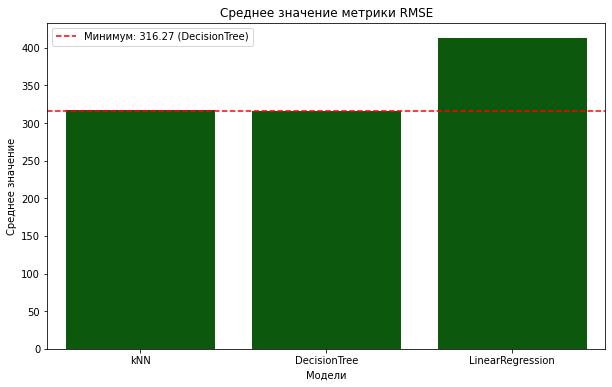

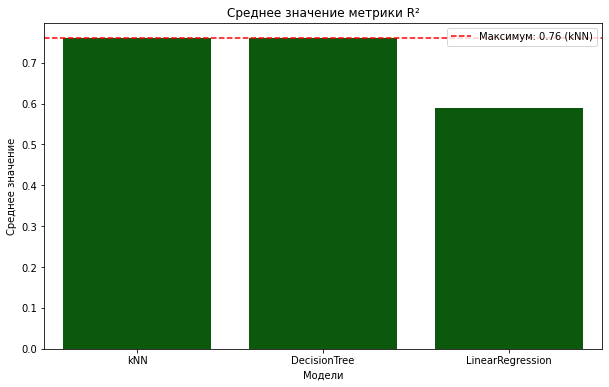

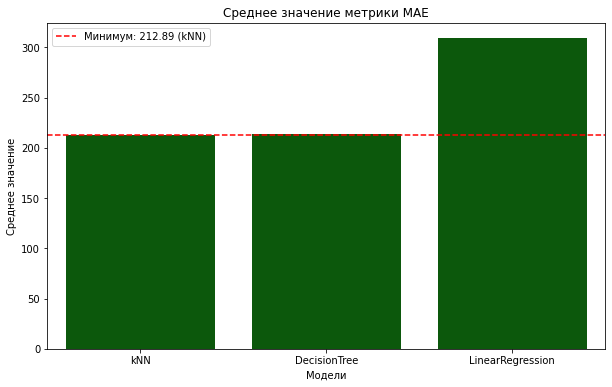

In [42]:
data_for_plot = data.T

for metric in data_for_plot.columns:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=data_for_plot.index, y=data_for_plot[metric], color='darkgreen')
    
    if metric == 'R²':
        plt.axhline(y=data_for_plot[metric].max(), color='red', linestyle='--', linewidth=1.5, 
                   label=f'Максимум: {data_for_plot[metric].max():.2f} ({data_for_plot[data_for_plot[metric] == data_for_plot[metric].max()].index[0]})')
    else:
        plt.axhline(y=data_for_plot[metric].min(), color='red', linestyle='--', linewidth=1.5, 
                   label=f'Минимум: {data_for_plot[metric].min():.2f} ({data_for_plot[data_for_plot[metric] == data_for_plot[metric].min()].index[0]})')
    
    plt.title(f'Среднее значение метрики {metric}')
    plt.ylabel('Среднее значение')
    plt.xlabel('Модели')
    plt.legend()
    plt.show()

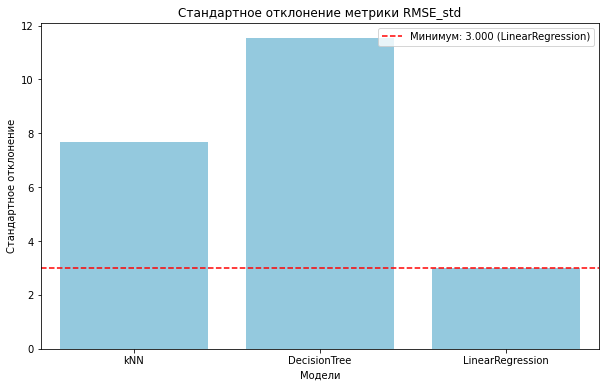

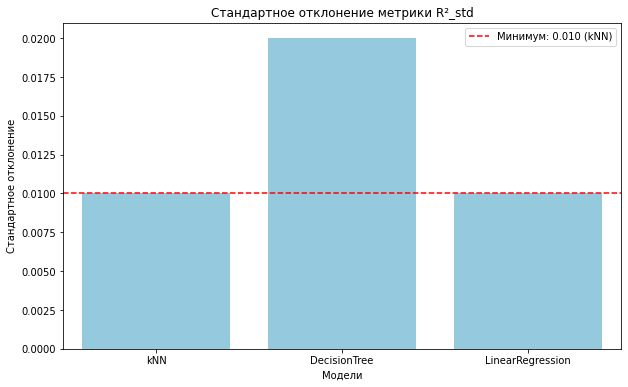

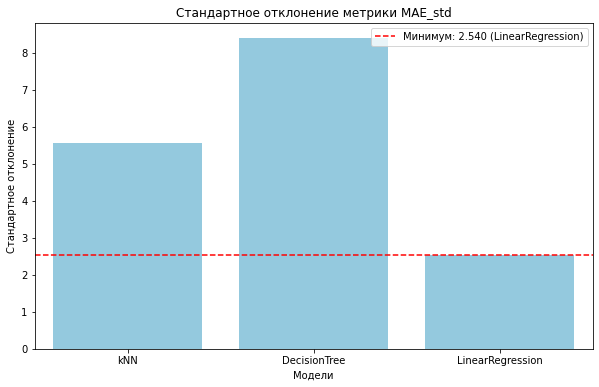

In [43]:
std_data_for_plot = std_data.T
for std in std_data_for_plot:
    plt.figure(figsize=(10, 6))
    sns.barplot(data=std_data_for_plot, x=std_data_for_plot.index, y=std, color='skyblue')
    
    plt.axhline(y=std_data_for_plot[std].min(), color='red', linestyle='--', linewidth=1.5, 
        label=f'Минимум: {std_data_for_plot[std].min():.3f} ({std_data_for_plot[std_data_for_plot[std] == std_data_for_plot[std].min()].index[0]})')
    
    plt.title(f'Стандартное отклонение метрики {std}')
    plt.ylabel('Стандартное отклонение')
    plt.xlabel('Модели')
    plt.legend()
    plt.show()

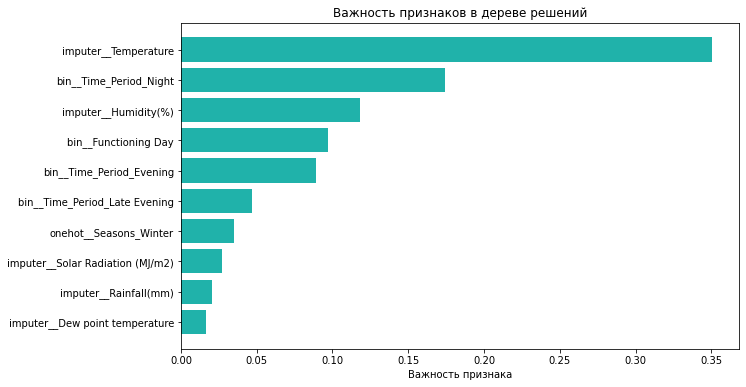

In [44]:
final_tree_pipeline.fit(X_train, y_train)

feature_importance = pd.DataFrame(
    {
        "feature": final_tree_pipeline.named_steps["preprocessor"].get_feature_names_out(),
        "importance": final_tree_pipeline.named_steps["tree"].feature_importances_,
    }
).sort_values("importance", ascending=False)

top_10_feature_names = feature_importance["feature"].values[:10]
top_10_feature_importance = feature_importance["importance"].values[:10]

plt.figure(figsize=(10, 6))
plt.barh(top_10_feature_names, top_10_feature_importance, color='lightseagreen')
plt.xlabel('Важность признака')
plt.title('Важность признаков в дереве решений')
plt.gca().invert_yaxis()
plt.show()

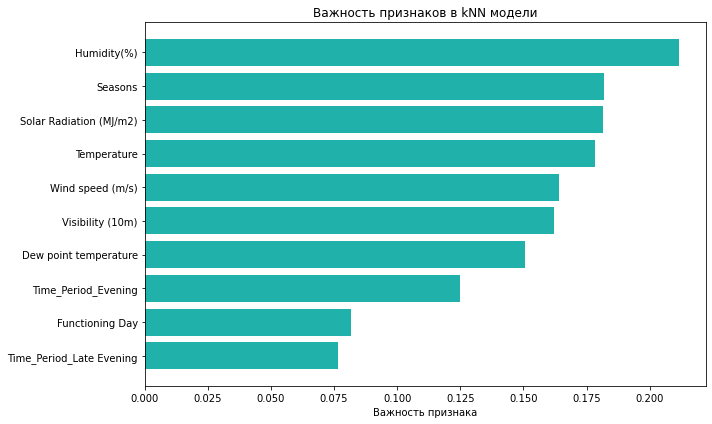

In [45]:
final_knn_pipeline.fit(X_train, y_train)

perm_importance = permutation_importance(
    final_knn_pipeline, 
    X_train, 
    y_train, 
    n_repeats=10,
    random_state=RANDOM_SEED,
    n_jobs=-1
)

feature_importance = pd.DataFrame(
    {
        "feature": X_train.columns, 
        "importance": perm_importance.importances_mean,
    }
).sort_values("importance", ascending=False)

top_10_feature_names = feature_importance["feature"].values[:10]
top_10_feature_importance = feature_importance["importance"].values[:10]

plt.figure(figsize=(10, 6))
plt.barh(top_10_feature_names[::-1], top_10_feature_importance[::-1], color='lightseagreen')
plt.xlabel("Важность признака")
plt.title("Важность признаков в kNN модели")
plt.tight_layout()
plt.show()

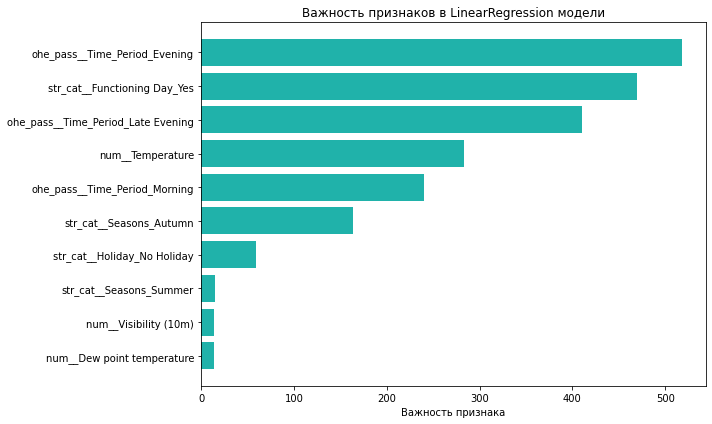

In [46]:
feature_importance = pd.DataFrame(
    {
        "feature": linear_model.named_steps["preprocessor"].get_feature_names_out(), 
        "importance": linear_model.named_steps["regressor"].coef_
    }
).sort_values("importance", ascending=False)

top_10_feature_names = feature_importance["feature"].values[:10]
top_10_feature_importance = feature_importance["importance"].values[:10]

plt.figure(figsize=(10, 6))
plt.barh(top_10_feature_names[::-1], top_10_feature_importance[::-1], color='lightseagreen')
plt.xlabel("Важность признака")
plt.title("Важность признаков в LinearRegression модели")
plt.tight_layout()
plt.show()

  - Обе модели: kNN и дерево решений на тренировочной выборке показали результаты лучше, чем базовая модель линейной регрессии
  - Модели kNN и дерево решений имеют почти одинаковые метрики, однако, kNN все-таки оказалась чуть лучше
  - С точки зрения стабильности метрик наилучшей моделью оказалась kNN, а самой нестабильной модель дерева решений
  - Среди наиболее важных признаков нелинейные модели выделяют: температуру воздуха, время суток, относительную влажность воздуха и солнечную радиацию
  
С точки зрения метрик и стабильности моделей наилучшей оказалась модель kNN

**Шаг 7. Сохранение модели и отчёта**

1. Выберите финальную, лучшую модель и оцените её качество на тестовой выборке, чтобы понять, насколько хорошо она прогнозирует на новых данных.
2. Подготовьте тетрадку с кодом и комментариями: включите результаты всех экспериментов, метрики моделей, визуализации, а также обоснование выбора финальной модели.

**Совет:**

Документируйте каждый шаг. Объясняйте, почему выбраны те или иные гиперпараметры и подходы. В реальной бизнес-задаче эта привычка поможет вашим коллегам и руководству понимать решения и доверять модели.

---



In [47]:
print('Оценка финальной модели на тестовой выборке')
y_pred_test_knn = final_knn_pipeline.predict(X_test)
print("RMSE:", round(root_mean_squared_error(y_test, y_pred_test_knn), 2))
print("MAE: ", round(mean_absolute_error(y_test, y_pred_test_knn), 2))
print("R²:  ", round(r2_score(y_test, y_pred_test_knn), 3))

Оценка финальной модели на тестовой выборке
RMSE: 313.07
MAE:  208.05
R²:   0.76


Метрики на тестовой выборке остались на том же уровне относительно тренировочной выборки, что свидетельствует о том, что модель не перееобучается
  - RMSE: 314.9 -> 317.6
  - R²: 0.76 -> 0.76
  - MAE: 214.61 -> 212.9

In [48]:
joblib.dump(final_knn_pipeline, 'knn_pipeline.joblib')

['knn_pipeline.joblib']

In [49]:
class KNNPredictor(object):
    
    def __init__(self):
        self._pipeline = joblib.load('knn_pipeline.joblib')
        self._RANDOM_SEED = 42
        
    def _process(self, X):
        # замена 0 во влажности на пустое
        X['Humidity(%)'] = X['Humidity(%)'].where(X['Humidity(%)']!=0)
        
        # бинарные признаки в True/False
        X['Holiday'] = X['Holiday'] == 'Holiday'
        X['Functioning Day'] = X['Functioning Day'] == 'Yes'
        
        return X
        
    def make_pred(self, X):
        ''' Предсказания модели '''
        
        X_processed = self._process(X)
        
        y_pred = self._pipeline.predict(X_processed)
        return y_pred
    
    @staticmethod
    def get_metrics(y_real, y_pred):
        print("RMSE:", round(root_mean_squared_error(y_real, y_pred), 2))
        print("MAE: ", round(mean_absolute_error(y_real, y_pred), 2))
        print("R²:  ", round(r2_score(y_real, y_pred), 3))

In [50]:
obj = KNNPredictor()
predictions = obj.make_pred(for_final.drop(columns='Rented Bike Count'))
obj.get_metrics(for_final['Rented Bike Count'], predictions)

RMSE: 313.07
MAE:  208.05
R²:   0.76


In [51]:
print("Проверка:")
np.allclose(predictions, final_knn_pipeline.predict(X_test))

Проверка:


True

    Отчет:
    - В ходе работы признаки 'holiday' и 'functioning_day' приведены к бинарному виду True/False
    - В признаке 'humidity(%)' аномальные значения с 0 были заменены на пустые значения
    - Для модели kNN:
        - Все пустые значения были заполнены медианой по данному признаку
        - Все признаки были стандартизированы с помощью StandardScaler
    - Для модели дерева решений:
        - Все пустые значения были заполнены медианой по данному признаку
    - Для обоих моделей с помощью optuna были подобраны оптимальные гиперпараметры
    - На тренировачных данных результаты моделей следующие:
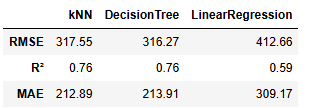
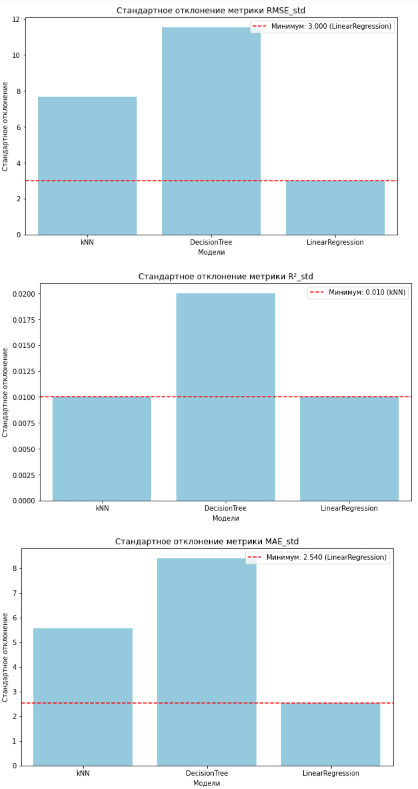

    - Ключевые метрики обоих построенных моделей оказались лучше базовой модели линейной регрессии
    - Среди наиболее важных признаков нелинейные модели выделяют: температуру воздуха, время суток, относительную влажность воздуха и солнечную радиацию
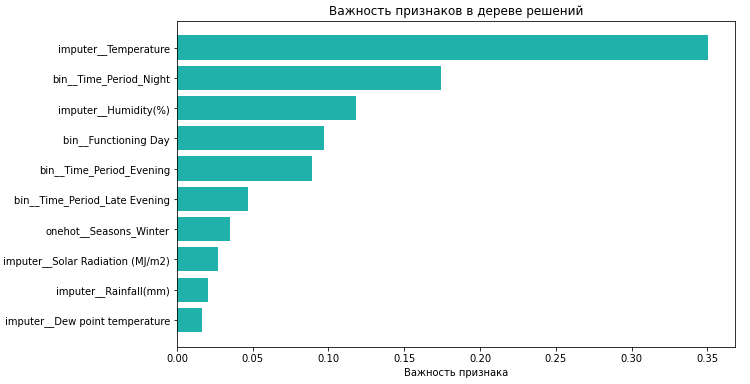
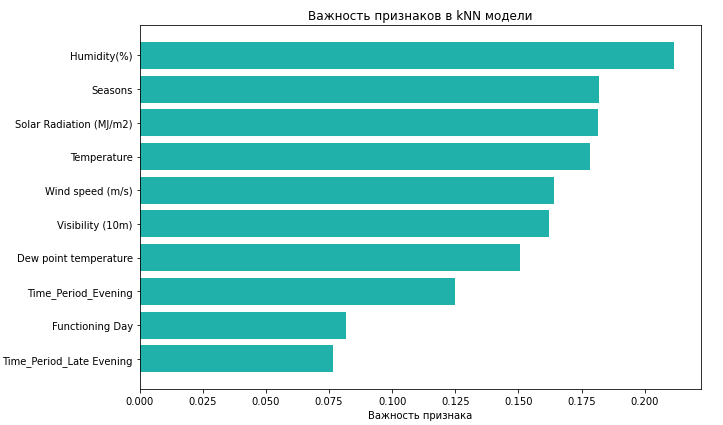

    - Наилучшей моделью с точки зрения стабильности и метрик оказалась kNN модель
    - Метрики на тестовой выборке остались на том же уровне относительно тренировочной выборки, что свидетельствует о том, что модель не перееобучается:
      * RMSE: 314.9 ->  317.6
      * R²: 0.76 -> 0.76
      * MAE: 214.61 -> 212.9.
    Цель проекта была достигнута, ключевые метрики kNN модели на тренировочной и тестовой выборках превосходят метрики базовой модели линейной регрессии

**Дополнительное задание: реализация кастомного трансформера**

Простые признаки вроде температуры или влажности не всегда отражают реальную ситуацию. Чтобы модель могла лучше прогнозировать спрос на велосипеды, можно создавать новые признаки, которые учитывают особенности погоды или взаимодействия факторов.

1. Реализуйте класс с методами `fit` и `transform`.
2. Вставьте его в пайплайн перед моделью.
3. Убедитесь, что трансформер корректно работает с тренировочными данными.

**Совет:**  
Если вы решите реализовать трансформер, начинайте с простых комбинаций признаков, чтобы не усложнять модель слишком рано.


---

